## Bifurcation Diagram

In [68]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [69]:
# plt.rcParams.update({
#     'font.size': 14,          # General font size
#     'axes.titlesize': 16,     # Subplot title size (e.g. "Distribution Sensitivity...")
#     'axes.labelsize': 15,     # X and Y axis label size
#     'xtick.labelsize': 12,    # Numbers on the X axis
#     'ytick.labelsize': 12,    # Numbers on the Y axis
#     'legend.fontsize': 12     # Legend text size
# })
plt.rcParams.update({
        'font.size': 18,          # General font size
        'axes.titlesize': 22,     # Subtitles & top case labels
        'axes.labelsize': 20,     # Axis labels (X and Y labels)
        'xtick.labelsize': 18,    # X-axis tick numbers
        'ytick.labelsize': 18,    # Y-axis tick numbers
        'legend.fontsize': 18     # Legend font size
    })

In [70]:
def calculate_k_from_l(l):
    keq = l[0]/l[1]
    k = np.array((keq*l[2], keq*l[3], l[4], l[5]))
    return k

In [71]:
def dx_versus_dt(kappa,a,b,x):
    y = kappa[0]*a*x**2-kappa[1]*x**3-kappa[3]*x+kappa[2]*b
    return y

x_axis = np.linspace(0,50,100000)
kappa_schloegl = np.array((0.15, 0.025, 5.75, 25))
y_axis = dx_versus_dt(kappa_schloegl,10,20,x_axis)
# plt.axhline(y=0.0)
# plt.plot(x_axis, y_axis, color='red')
# plt.xlabel('x')
# plt.ylabel('dx/dt')
# plt.show()

In [72]:
def get_steady_states_l1p(p):
    l = np.array((p, 1500., 150., 25., 5.75, 25.))
    k = calculate_k_from_l(l)
    a=10.
    b=20.
    coeffs = [-k[1], k[0]*a, -k[3], k[2]*b]
    roots = np.roots(coeffs)

    real_roots = np.sort(roots[np.isreal(roots)].real)
    return real_roots


In [73]:
def get_analytical_dist(p_max, kappa, a, b, vol):
    lamb_n = lambda y: a*kappa[0]*y*(y-1)/vol + b*kappa[2]*vol
    mu_n = lambda y: y*kappa[3] + kappa[1]*y*(y-1)*(y-2)/(vol**2)
    
    # We will compute log(P(n)) to avoid numerical underflow/overflow
    log_p = np.zeros(p_max)
    log_p[0] = 0.0 # Arbitrary unnormalized start
    
    for n in range(1, p_max):
        log_p[n] = log_p[n-1] + np.log(lamb_n(n-1)) - np.log(mu_n(n))
        
    # Subtract max to prevent overflow when doing np.exp()
    log_p -= np.max(log_p)
    
    # Convert back to standard probability and normalize
    p_dist = np.exp(log_p)
    p_dist /= np.sum(p_dist) 
    
    return p_dist



In [74]:
def get_steady_states_l2ratio(p):
    l = np.array((1.5, 1500., 25*p, 25., 5.75, 25.))
    k = calculate_k_from_l(l)
    a=10.
    b=20.
    coeffs = [-k[1], k[0]*a, -k[3], k[2]*b]
    roots = np.roots(coeffs)

    real_roots = np.sort(roots[np.isreal(roots)].real)
    return real_roots

In [75]:
# Sweep the parameter from 1.0 to 2.0
parameter_sweep_l1p = np.linspace(1.0, 2.0, 1000)
# Sweep the parameter from 1.0 to 2.0
# parameter_sweep_l1p_smaller = np.linspace(1.495, 1.505, 10)
## parameter_sweep = np.linspace(1.45, 1.55, 500) # 1.495, 1.505, 50
# Sweep the parameter from 5.0 to 7.0
parameter_sweep_l2ratio = np.linspace(5.5, 6.5, 1000)

In [76]:

stable_x_l1 = []
stable_y_l1 = []
unstable_x_l1 = []
unstable_y_l1 = []

for p in parameter_sweep_l1p:
    roots = get_steady_states_l1p(p)
    
    if len(roots) == 1:
        # Only one stable state
        stable_x_l1.append(p)
        stable_y_l1.append(roots[0])
    elif len(roots) == 3:
        # Three states: top and bottom are stable, middle is unstable
        stable_x_l1.append(p)
        stable_y_l1.append(roots[0])
        
        unstable_x_l1.append(p)
        unstable_y_l1.append(roots[1])
        
        stable_x_l1.append(p)
        stable_y_l1.append(roots[2])

stable_x_l2 = []
stable_y_l2 = []
unstable_x_l2 = []
unstable_y_l2 = []

for p in parameter_sweep_l2ratio:
    roots = get_steady_states_l2ratio(p)
    
    if len(roots) == 1:
        # Only one stable state
        stable_x_l2.append(p)
        stable_y_l2.append(roots[0])
    elif len(roots) == 3:
        # Three states: top and bottom are stable, middle is unstable
        stable_x_l2.append(p)
        stable_y_l2.append(roots[0])
        
        unstable_x_l2.append(p)
        unstable_y_l2.append(roots[1])
        
        stable_x_l2.append(p)
        stable_y_l2.append(roots[2])


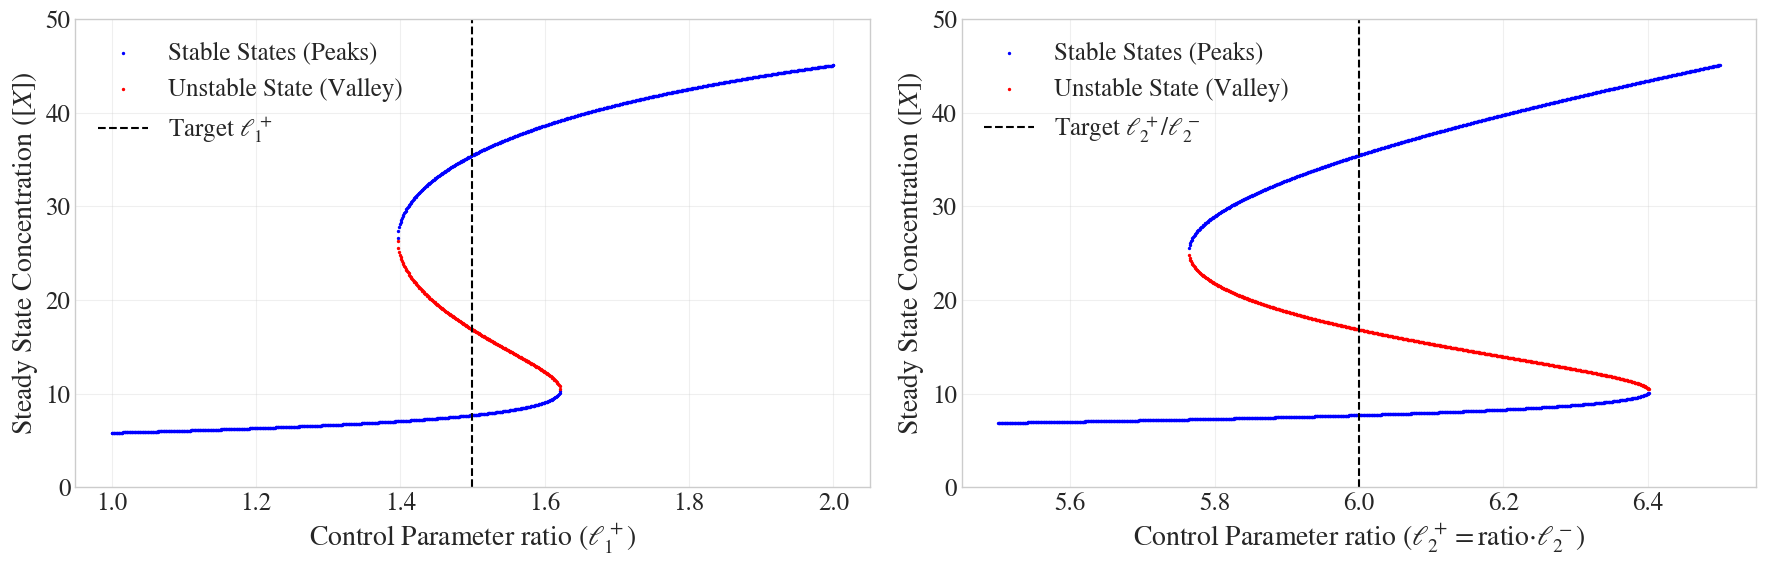

In [77]:

# Plotting
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18, 6))
# Plot the stable branches
ax1.scatter(stable_x_l1, stable_y_l1, color='blue', s=2, label='Stable States (Peaks)')

# Plot the unstable branch
if unstable_x_l1:
    ax1.scatter(unstable_x_l1, unstable_y_l1, color='red', s=2, label='Unstable State (Valley)')

# Draw a line showing our "target" parameter
ax1.axvline(x=1.5, color='black', linestyle='--', label='Target $\ell_1^+$')

# plt.title("Bifurcation Diagram of the Schlögl Model")
ax1.set_xlabel("Control Parameter ratio ($\ell_1^+$)")
ax1.set_ylabel("Steady State Concentration ($[X]$)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0,50)
# Plot the stable branches
ax2.scatter(stable_x_l2, stable_y_l2, color='blue', s=2, label='Stable States (Peaks)')

# Plot the unstable branch
if unstable_x_l2:
    ax2.scatter(unstable_x_l2, unstable_y_l2, color='red', s=2, label='Unstable State (Valley)')

# Draw a line showing our "target" parameter
ax2.axvline(x=6.0, color='black', linestyle='--', label='Target $\ell_2^+/\ell_2^-$')
ax2.set_xlabel("Control Parameter ratio ($\ell_2^+=$ratio$\cdot \ell_2^-$)")
ax2.set_ylabel("Steady State Concentration ($[X]$)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0,50)
fig.tight_layout()
# plt.show()

In [87]:

# 1. Set a clean scientific style
plt.style.use('seaborn-v0_8-whitegrid') # or just 'seaborn-whitegrid' depending on matplotlib version
plt.rcParams.update({
        'font.size': 16,          # General font size
        'axes.titlesize': 18,     # Subtitles & top case labels
        'axes.labelsize': 18,     # Axis labels (X and Y labels)
        'xtick.labelsize': 16,    # X-axis tick numbers
        'ytick.labelsize': 16,    # Y-axis tick numbers
        'legend.fontsize': 16     # Legend font size
    })
# 2. Define a continuous colormap (e.g., 'viridis', 'plasma', or 'coolwarm')
# 'coolwarm' is great because it shows a transition from cold (low) to hot (high)

# For the left plot (keep it coolwarm or RdBu)
cmap1 = plt.get_cmap('coolwarm') 
# For the right plot (change to PRGn - Purple to Green)
cmap2 = plt.get_cmap('coolwarm') # 'coolwarm'



In [88]:
parameter_sweep_l1p = np.linspace(1.49, 1.51, 100)
parameter_sweep_l2ratio = np.linspace(5.95, 6.05, 250) # 5.95, 6.05, 50 # 5.5, 6.5, 500

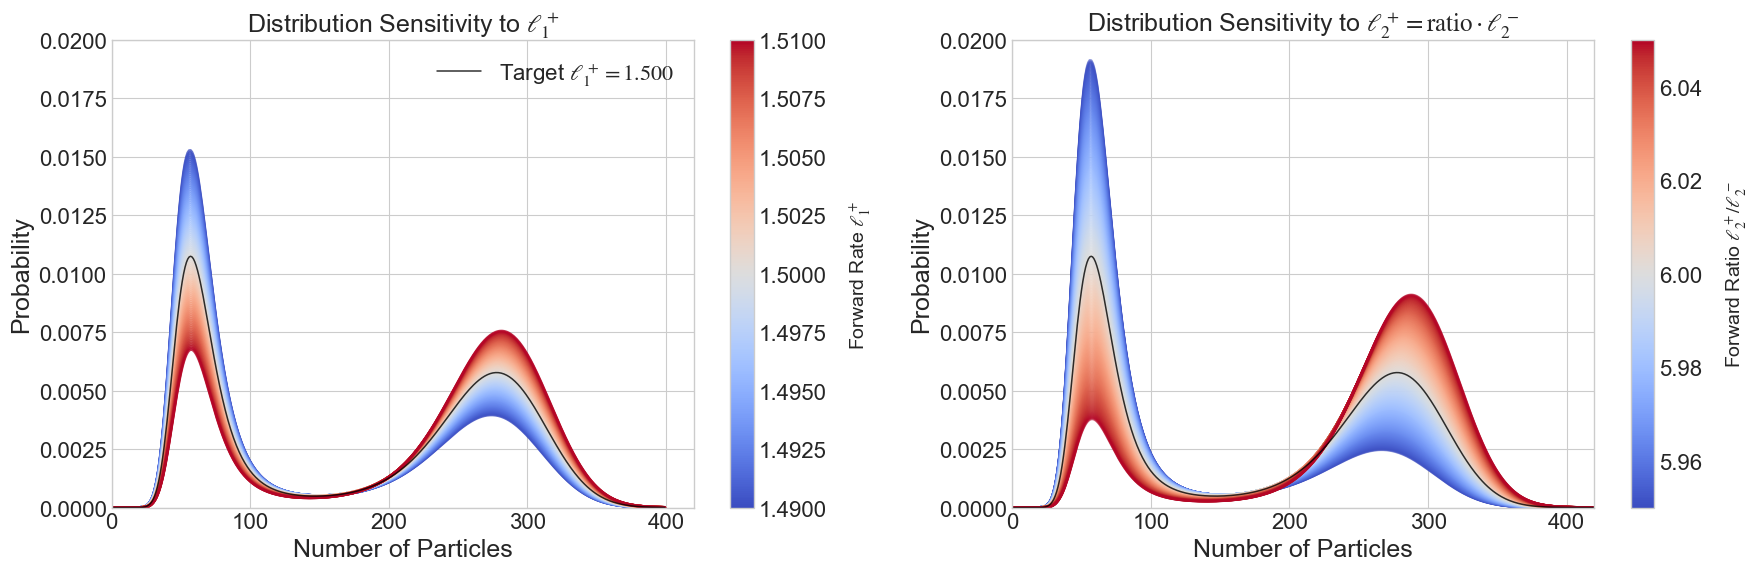

In [89]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18, 6))
a, b = 10, 20
# Suppose l1p_values is your list/array of l1p values
l1p_min = min(parameter_sweep_l1p)
l1p_max = max(parameter_sweep_l1p)
# 3. Plot each line using the colormap
for i, l1p in enumerate(parameter_sweep_l1p):
    # Normalize the current l1p value between 0 and 1 for the colormap
    color_intensity = (l1p - l1p_min) / (l1p_max - l1p_min)
    color = cmap1(color_intensity)
    x_data = np.arange(400)
    l = np.array((l1p, 1500., 150., 25., 5.75, 25.))
    k = calculate_k_from_l(l)
    y_data = get_analytical_dist(400, k, a, b, vol=8.)
    # Plot without a legend label
    ax1.plot(x_data, y_data, color=color, linewidth=2, alpha=0.8)
# the exact one:
l = np.array((1.5, 1500., 150., 25., 5.75, 25.))
k = calculate_k_from_l(l)
y_data = get_analytical_dist(400, k, a, b, vol=8.)
# Plot without a legend label
ax1.plot(x_data, y_data, color='black', linewidth=1.1, alpha=0.8, label=r'Target $\ell_1^+ = 1.500$')
# 4. Add a colorbar instead of a legend
sm = plt.cm.ScalarMappable(cmap=cmap1, norm=plt.Normalize(vmin=l1p_min, vmax=l1p_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1)
cbar.set_label(r'Forward Rate $\ell_1^+$', fontsize=14, labelpad=15)

# 5. Clean up axes and labels
ax1.set_xlabel(r'Number of Particles') #  ($n_X$)
ax1.set_ylabel(r'Probability') #  $P(n_X)
ax1.set_title(r'Distribution Sensitivity to $\ell_1^+$')
ax1.set_xlim(0,420)
ax1.set_ylim(0,0.02)
# Optional: Add a subtle highlight for your target value
# If you have the data for the exact target (1.500), you can plot it thicker/black
# ax.plot(x_data_target, y_data_target, color='black', linewidth=2.5, linestyle='--', label=r'Target $\ell_1^+ = 1.500$')
ax1.legend()

# Suppose l1p_values is your list/array of l1p values
ratio_min = min(parameter_sweep_l2ratio)
ratio_max = max(parameter_sweep_l2ratio)

# 3. Plot each line using the colormap
for i, ratio in enumerate(parameter_sweep_l2ratio):
    # Normalize the current l1p value between 0 and 1 for the colormap
    color_intensity = (ratio - ratio_min) / (ratio_max - ratio_min)
    color = cmap2(color_intensity)
    x_data = np.arange(500)
    # l = np.array((1.5, 1500., 150., 150./ratio, 5.75, 25.))
    l = np.array((1.5, 1500., 25.*ratio, 25., 5.75, 25.))
    k = calculate_k_from_l(l)
    y_data = get_analytical_dist(500, k, a, b, vol=8.)
    # Plot without a legend label
    ax2.plot(x_data, y_data, color=color, linewidth=2, alpha=0.6)
# the exact one:
l = np.array((1.5, 1500., 150., 25., 5.75, 25.))
k = calculate_k_from_l(l)
y_data = get_analytical_dist(500, k, a, b, vol=8.)
# Plot without a legend label
ax2.plot(x_data, y_data, color='black', linewidth=1.1, alpha=0.8, label=r'Target $K_{eq}= 6.000$')
# 4. Add a colorbar instead of a legend
sm = plt.cm.ScalarMappable(cmap=cmap2, norm=plt.Normalize(vmin=ratio_min, vmax=ratio_max))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax2)
cbar.set_label(r'Forward Ratio $\ell_2^+/\ell_2^-$', fontsize=14, labelpad=15)

# 5. Clean up axes and labels
ax2.set_xlim(0,420)
ax2.set_ylim(0,0.02)
ax2.set_xlabel(r'Number of Particles') #($N_X$)
ax2.set_ylabel(r'Probability') #  $P(N_X)$
ax2.set_title(r'Distribution Sensitivity to $\ell_2^+=\text{ratio}\cdot\ell_2^-$')
fig.tight_layout()
